In [2]:
import pandas as pd
import sklearn
from sklearn.datasets import fetch_openml
from glum import GeneralizedLinearRegressor, GeneralizedLinearRegressorCV

In [3]:
house_data = fetch_openml(name="house_sales", version=3, as_frame=True)

# Use only select features
X = house_data.data[
    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "floors",
        "waterfront",
        "view",
        "condition",
        "grade",
        "yr_built",
    ]
].copy()

# Targets
y = house_data.target

In [4]:
df = house_data.data
df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date_year,date_month,date_day
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,13
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,9
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,25
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,9
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,...,2009,0,98103,47.6993,-122.346,1530,1509,2014,5,21
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,...,2014,0,98146,47.5107,-122.362,1830,7200,2015,2,23
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,...,2009,0,98144,47.5944,-122.299,1020,2007,2014,6,23
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,...,2004,0,98027,47.5345,-122.069,1410,1287,2015,1,16


In [5]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.3, random_state=5
)

# GLM model

In [20]:
glm = GeneralizedLinearRegressor(family="normal", alpha=0.1, l1_ratio=1, fit_intercept=True)
glm.fit(X_train, y_train)


GeneralizedLinearRegressor(alpha=0.1, l1_ratio=1)

In [30]:
# retrieve the coefficients and the intercept
coefs = glm.coef_
intercept = glm.intercept_
features = X_train.columns.tolist()

intercept_row = pd.DataFrame({"feature": ["intercept"], "coefs": [intercept]})
result = pd.concat([intercept_row, 
    pd.DataFrame(
   {"feature": features,
    "coefs": coefs}
)], axis=0)

result

,feature,coefs
0,intercept,6.339275e+06
0,bedrooms,-3.622347e+04
1,bathrooms,4.684291e+04
2,sqft_living,1.640180e+02
3,floors,2.380130e+04
4,waterfront,5.459541e+05
5,view,4.530984e+04
6,condition,1.859039e+04
7,grade,1.259248e+05
8,yr_built,-3.651241e+03


In [ ]:
# use the model to predict on our test data
preds = glm.predict(X_test)

preds[0:5]

array([ 482648.22861011,  142902.68859953,  539452.61266457,
        569693.78048651, 1042446.90903448])

In [31]:
glmcv = GeneralizedLinearRegressorCV(
    family="normal",
    alphas=None,  # default
    min_alpha=None,  # default
    min_alpha_ratio=None,  # default
    l1_ratio=[0, 0.5, 1.0],
    fit_intercept=True,
    max_iter=150
)
glmcv.fit(X_train, y_train)
print(f"Chosen alpha:    {glmcv.alpha_}")
print(f"Chosen l1 ratio: {glmcv.l1_ratio_}")

Chosen alpha:    0.0003274549162877732
Chosen l1 ratio: 0.0


# Check

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytest
import scipy.optimize as optimize
import scipy.stats
from dask_ml.preprocessing import Categorizer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import ShuffleSplit
from glum import GeneralizedLinearRegressor
from glum import TweedieDistribution



ModuleNotFoundError: No module named 'load_transform_formula'

In [ ]:
from sklearn.datasets import fetch_openml

# Load dataset from OpenML (adjust ID if needed)
data = fetch_openml(data_id=41214, as_frame=True)  # 'as_frame=True' gives you a pandas DataFrame
df = data.frame

# Display the first few rows
df.head()
with pd.option_context('display.max_rows', 10):
    display(df)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10000,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77000,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75000,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09000,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84000,B,7,0,46,50,B12,'Diesel',76,R72
...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,E,4,0,54,50,B12,'Regular',3317,R93
678009,6114327.0,0,0.00274,E,4,0,41,95,B12,'Regular',9850,R11
678010,6114328.0,0,0.00274,D,6,2,45,50,B12,'Diesel',1323,R82
678011,6114329.0,0,0.00274,B,4,0,60,50,B12,'Regular',95,R26


In [ ]:
ss = ShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train, test = next(ss.split(df))

df = df.assign(PurePremium=lambda x: x["ClaimAmountCut"] / x["Exposure"])

glm_categorizer = Categorizer(
    columns=["VehBrand", "VehGas", "Region", "Area", "DrivAge", "VehAge", "VehPower"]
)
df_train = glm_categorizer.fit_transform(df.iloc[train])
df_test = glm_categorizer.transform(df.iloc[test])

KeyError: 'ClaimAmountCut'

ValueError: p only valid for 1 < p < 2

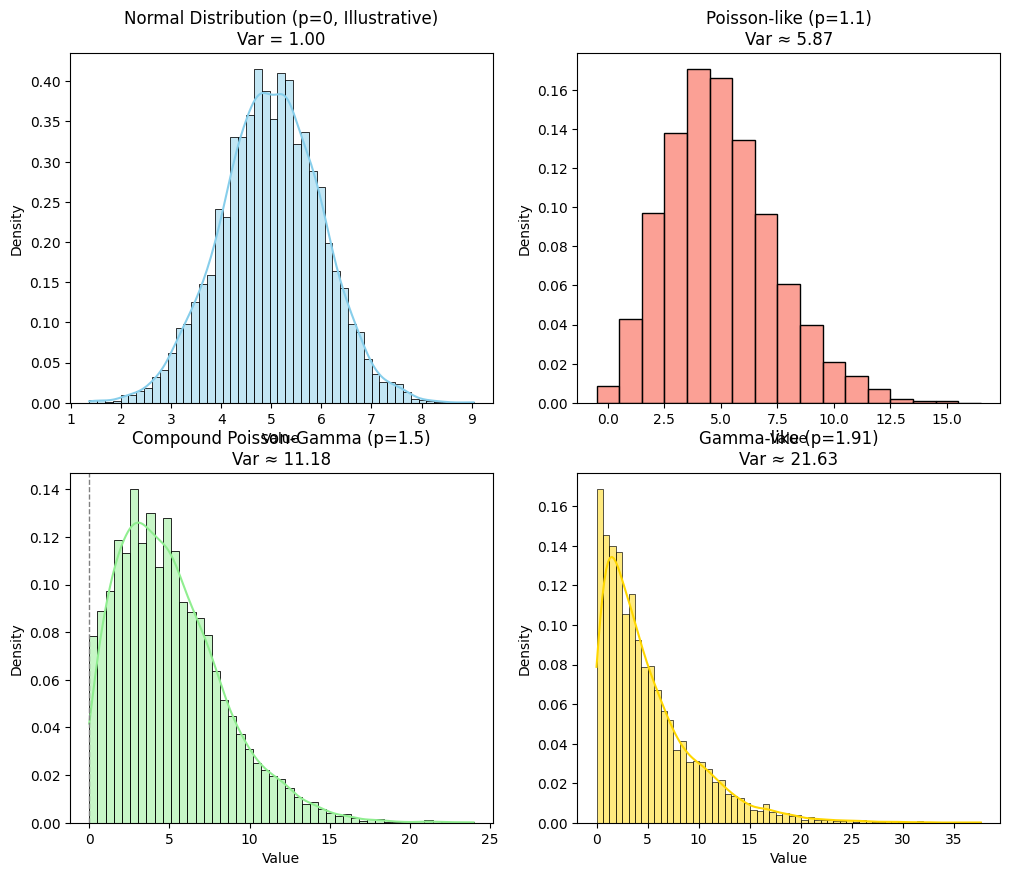

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tweedie import tweedie # You might need to install this: pip install tweedie

# --- Parameters for visualization ---
n_samples = 5000
mu_val = 5  # Mean
phi_val = 1 # Dispersion

# --- Generate and plot for different power parameters (p) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# p = 0 (Normal) - Note: tweedie package might not directly support p=0,
# so we'll use numpy's normal for illustration.
# For p=0, Var = phi * mu^0 = phi
p_normal = 0
samples_normal = np.random.normal(loc=mu_val, scale=np.sqrt(phi_val), size=n_samples)
sns.histplot(samples_normal, kde=True, ax=axes[0], stat="density", color="skyblue")
axes[0].set_title(f'Normal Distribution (p={p_normal}, Illustrative)\nVar = {phi_val:.2f}')
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

# p = 1 (Poisson-like) - Note: tweedie package handles p >= 1
# For p=1, Var = phi * mu^1 = phi * mu
p_poisson_like = 1.1 # True Poisson has phi=1
samples_poisson_like = tweedie(mu=mu_val, p=p_poisson_like, phi=phi_val).rvs(n_samples)
sns.histplot(samples_poisson_like, kde=False, ax=axes[1], stat="density", discrete=True, color="salmon")
axes[1].set_title(f'Poisson-like (p={p_poisson_like})\nVar ≈ {phi_val * mu_val**p_poisson_like:.2f}')
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")

# p = 1.5 (Compound Poisson-Gamma)
# For p=1.5, Var = phi * mu^1.5
p_compound = 1.5
samples_compound = tweedie(mu=mu_val, p=p_compound, phi=phi_val).rvs(n_samples)
sns.histplot(samples_compound, kde=True, ax=axes[2], stat="density", color="lightgreen")
axes[2].set_title(f'Compound Poisson-Gamma (p={p_compound})\nVar ≈ {phi_val * mu_val**p_compound:.2f}')
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Density")
axes[2].axvline(0, color='grey', linestyle='--', lw=1) # Highlight potential mass at zero

# p = 2 (Gamma-like)
# For p=2, Var = phi * mu^2
p_gamma_like = 1.91
samples_gamma_like = tweedie(mu=mu_val, p=p_gamma_like, phi=phi_val).rvs(n_samples)
sns.histplot(samples_gamma_like, kde=True, ax=axes[3], stat="density", color="gold")
axes[3].set_title(f'Gamma-like (p={p_gamma_like})\nVar ≈ {phi_val * mu_val**p_gamma_like:.2f}')
axes[3].set_xlabel("Value")
axes[3].set_ylabel("Density")

p_gamma_like = 3
samples_gamma_like = tweedie(mu=mu_val, p=p_gamma_like, phi=phi_val).rvs(n_samples)
sns.histplot(samples_gamma_like, kde=True, ax=axes[3], stat="density", color="gold")
axes[3].set_title(f'Gamma-like (p={p_gamma_like})\nVar ≈ {phi_val * mu_val**p_gamma_like:.2f}')
axes[3].set_xlabel("Value")
axes[3].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulate Data ---
np.random.seed(42)
n_samples = 1000

# Feature 1: e.g., driver's age (scaled)
X1 = np.random.rand(n_samples) * 30 + 18
# Feature 2: e.g., vehicle value (scaled)
X2 = np.random.rand(n_samples) * 5 + 1

# True coefficients
beta0 = 0.5  # Intercept
beta1 = 0.03 # Effect of X1
beta2 = 0.1  # Effect of X2

# Linear predictor with a log link
log_mu = beta0 + beta1 * (X1 - X1.mean()) + beta2 * (X2 - X2.mean())
mu = np.exp(log_mu)

# Generate Tweedie distributed target variable (e.g., claim cost)
# We'll use power = 1.5 (Compound Poisson-Gamma) and a dispersion parameter
power = 1.5
phi = 2.5 # Dispersion

# For p between 1 and 2, Tweedie can be seen as a Poisson sum of Gamma variables.
# lambda for Poisson part
lambda_poisson = mu**(2 - power) / (phi * (2 - power))
# shape for Gamma part
alpha_gamma = (2 - power) / (1 - power)
# scale for Gamma part
scale_gamma = phi * (power - 1) * mu**(power - 1)

y = []
for i in range(n_samples):
    num_claims = np.random.poisson(lambda_poisson[i])
    if num_claims == 0:
        y.append(0)
    else:
        total_claim_amount = np.sum(np.random.gamma(shape=alpha_gamma, scale=scale_gamma[i], size=num_claims))
        y.append(total_claim_amount)
y = np.array(y)

df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

# --- 2. Prepare Data for GLM ---
X = df[['X1', 'X2']]
y_target = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

# --- 3. Fit Tweedie Regressor ---
# We assume we know the power parameter (or it can be tuned via cross-validation)
# GLUM would also allow specifying the power.
# Common link for Tweedie is 'log'.
tweedie_model = TweedieRegressor(power=power, link='log', alpha=0.01) # alpha is L2 penalty strength
tweedie_model.fit(X_train, y_train)

# --- 4. Make Predictions and Evaluate (Simplified) ---
y_pred_train = tweedie_model.predict(X_train)
y_pred_test = tweedie_model.predict(X_test)

print(f"Intercept: {tweedie_model.intercept_:.4f} (True: ~{beta0})") # Note: True intercept is on log scale
print(f"Coefficients: {tweedie_model.coef_} (True: [{beta1}, {beta2}])")


# --- 5. Visualize Results (Actual vs. Predicted) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.5)
plt.plot([min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())],
         [min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())],
         'r--')
plt.title('Training Data: Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
plt.plot([min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())],
         [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())],
         'r--')
plt.title('Test Data: Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)

plt.tight_layout()
plt.show()

# Visualize distribution of residuals (on log scale for better visibility if skewed)
residuals_test = y_test - y_pred_test
plt.figure(figsize=(8, 6))
sns.histplot(residuals_test, kde=True)
plt.title('Distribution of Residuals (Test Set)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='r', linestyle='--')
plt.grid(True)
plt.show()

ValueError: shape < 0